In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using device: {device}")

Using device: mps


In [2]:
# CIFAR-10 has different normalization stats than MNIST (3 color channels)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

train_data = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_data = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# CIFAR-10 class names (the dataset just gives integers 0-9)
class_names = ['airplane', 'car', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print(f"Training samples: {len(train_data)}")
print(f"Test samples: {len(test_data)}")

image, label = train_data[0]
print(f"Image shape: {image.shape}")
print(f"Label: {label} ({class_names[label]})")

100.0%
/Users/yanizhang/Documents/projects/robotics-ramp/.venv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Training samples: 50000
Test samples: 10000
Image shape: torch.Size([3, 32, 32])
Label: 6 (frog)


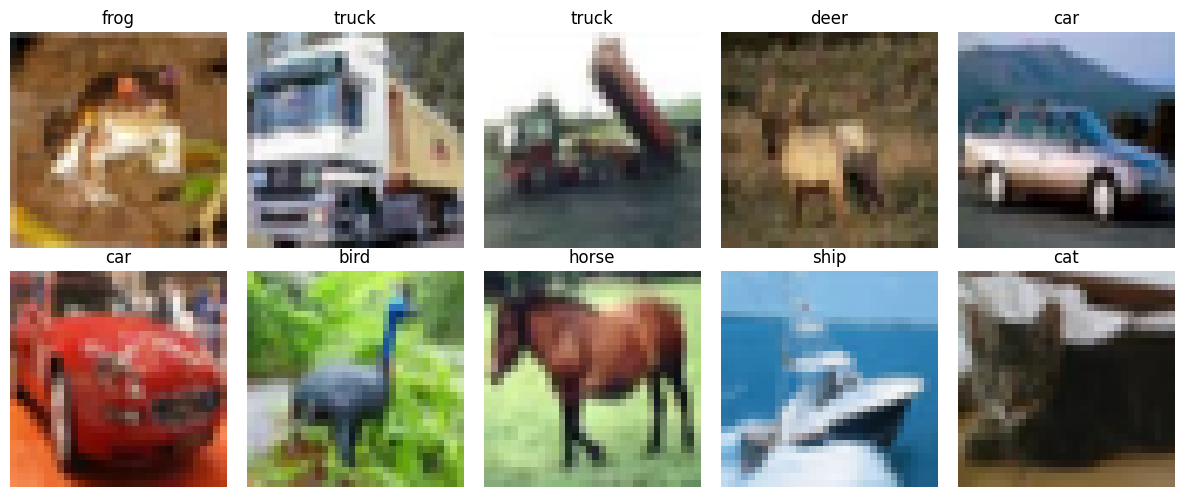

In [3]:
def denormalize(tensor):
    """Reverse the normalization for display."""
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)
    return tensor * std + mean

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(10):
    image, label = train_data[i]
    image_display = denormalize(image).clamp(0, 1)
    image_display = image_display.permute(1, 2, 0).numpy()  # [3, 32, 32] -> [32, 32, 3]

    ax = axes[i // 5, i % 5]
    ax.imshow(image_display)
    ax.set_title(f"{class_names[label]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

In [4]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Convolutional block 1: 3 -> 32 channels, then downsample
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Convolutional block 2: 32 -> 64 channels, then downsample
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Classifier head
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 10)

        self.relu = nn.ReLU()

    def forward(self, x):
        # Block 1
        x = self.relu(self.conv1(x))   # [batch, 3, 32, 32] -> [batch, 32, 32, 32]
        x = self.relu(self.conv2(x))   # [batch, 32, 32, 32] -> [batch, 32, 32, 32]
        x = self.pool1(x)              # [batch, 32, 32, 32] -> [batch, 32, 16, 16]

        # Block 2
        x = self.relu(self.conv3(x))   # [batch, 32, 16, 16] -> [batch, 64, 16, 16]
        x = self.relu(self.conv4(x))   # [batch, 64, 16, 16] -> [batch, 64, 16, 16]
        x = self.pool2(x)              # [batch, 64, 16, 16] -> [batch, 64, 8, 8]

        # Classifier
        x = self.flatten(x)            # [batch, 64, 8, 8] -> [batch, 4096]
        x = self.relu(self.fc1(x))     # [batch, 4096] -> [batch, 128]
        x = self.dropout(x)
        x = self.fc2(x)                # [batch, 128] -> [batch, 10]
        return x

model = SimpleCNN().to(device)
print(model)

# Count parameters — useful sanity check
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")

SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
)

Total parameters: 591,274


In [5]:
batch_size = 128
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=2)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [6]:
num_epochs = 10

train_losses = []
test_accuracies = []

for epoch in range(num_epochs):
    # ---- Training ----
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        predictions = model(images)
        loss = loss_fn(predictions, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    # ---- Evaluation after each epoch ----
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            predictions = model(images)
            predicted_classes = predictions.argmax(dim=1)
            correct += (predicted_classes == labels).sum().item()
            total += labels.size(0)

    accuracy = 100 * correct / total
    test_accuracies.append(accuracy)

    print(f"Epoch {epoch+1}/{num_epochs} — loss: {avg_loss:.4f} — test acc: {accuracy:.2f}%")

print("\nTraining done.")

Epoch 1/10 — loss: 1.5968 — test acc: 56.53%
Epoch 2/10 — loss: 1.2057 — test acc: 64.21%
Epoch 3/10 — loss: 1.0227 — test acc: 69.53%
Epoch 4/10 — loss: 0.8999 — test acc: 72.32%
Epoch 5/10 — loss: 0.8114 — test acc: 73.55%
Epoch 6/10 — loss: 0.7462 — test acc: 74.44%
Epoch 7/10 — loss: 0.6946 — test acc: 76.05%
Epoch 8/10 — loss: 0.6397 — test acc: 75.76%
Epoch 9/10 — loss: 0.5989 — test acc: 75.86%
Epoch 10/10 — loss: 0.5574 — test acc: 77.05%

Training done.


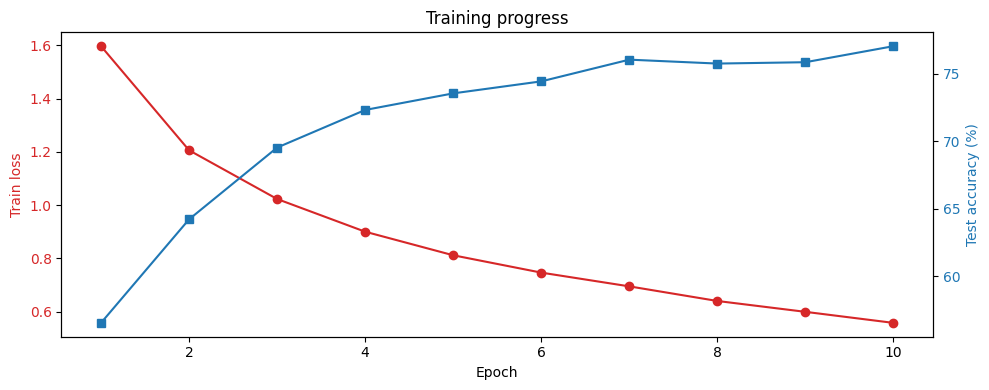

In [7]:
fig, ax1 = plt.subplots(figsize=(10, 4))

color1 = 'tab:red'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Train loss', color=color1)
ax1.plot(range(1, num_epochs + 1), train_losses, color=color1, marker='o')
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()  # Second y-axis sharing the x-axis
color2 = 'tab:blue'
ax2.set_ylabel('Test accuracy (%)', color=color2)
ax2.plot(range(1, num_epochs + 1), test_accuracies, color=color2, marker='s')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Training progress')
plt.tight_layout()
plt.show()

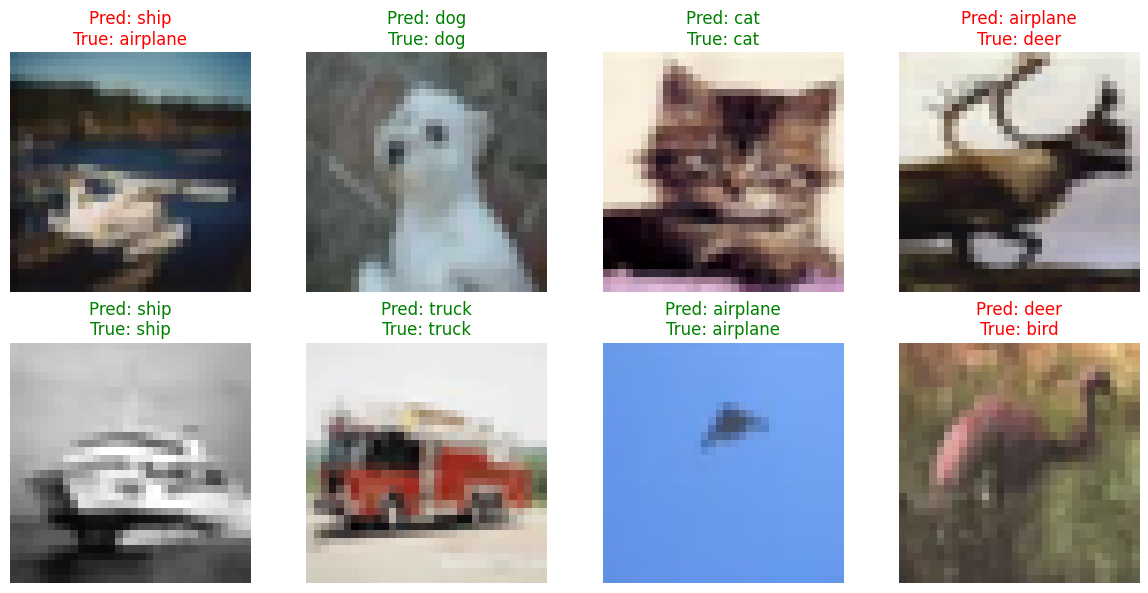

In [8]:
import random
indices = random.sample(range(len(test_data)), 8)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
model.eval()
with torch.no_grad():
    for i, idx in enumerate(indices):
        image, true_label = test_data[idx]
        prediction = model(image.unsqueeze(0).to(device)).argmax(dim=1).item()

        # Prepare image for display
        image_display = denormalize(image).clamp(0, 1).permute(1, 2, 0).numpy()

        ax = axes[i // 4, i % 4]
        ax.imshow(image_display)
        color = 'green' if prediction == true_label else 'red'
        ax.set_title(f"Pred: {class_names[prediction]}\nTrue: {class_names[true_label]}", color=color)
        ax.axis('off')
plt.tight_layout()
plt.show()

In [9]:
# Compute per-class accuracy
class_correct = [0] * 10
class_total = [0] * 10

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        predictions = model(images).argmax(dim=1)
        for i in range(labels.size(0)):
            label = labels[i].item()
            class_total[label] += 1
            if predictions[i].item() == label:
                class_correct[label] += 1

print(f"{'Class':<12} {'Accuracy':>10}")
print("-" * 24)
for i in range(10):
    acc = 100 * class_correct[i] / class_total[i]
    print(f"{class_names[i]:<12} {acc:>9.2f}%")

Class          Accuracy
------------------------
airplane         82.00%
car              87.00%
bird             62.00%
cat              62.10%
deer             69.80%
dog              70.00%
frog             80.00%
horse            79.80%
ship             89.90%
truck            87.90%
